# Load and visualize Allen embeddings + frame decoding

Uses **only** `.npy` train/test embeddings under `Flow_Hackathon/data/allen_data` (no `cebra` package).

Neuropixel decoding follows the same `allen_frame_id_decode` setup as `Demo_Allen.ipynb` (kNN on saved embeddings).

In [4]:
# Optional: pip install scikit-learn matplotlib numpy
# !pip install -q scikit-learn matplotlib numpy

### Step 1: Paths and load embeddings from `allen_data/`

In [5]:
from pathlib import Path

import numpy as np

DATA_DIR = Path("/home/fachengy/flow/Flow_Hackathon/data/allen_data").resolve()
seed = 333
# Match `Demo_Allen` disjoint cortex1 save names (VISp) or legacy `cortex1_*`
AREA = "VISp"


def _load_npy(*candidates: Path) -> np.ndarray:
    for p in candidates:
        if p is not None and p.is_file():
            return np.load(p)
    tried = [str(p) for p in candidates if p is not None]
    raise FileNotFoundError(
        "No embedding file found. Tried:\n  " + "\n  ".join(tried)
    )


# Train Ca / NP (joint model)
ca_emb = _load_npy(
    DATA_DIR / f"{AREA}_joint_trained_ca_{seed}_train.npy",
    DATA_DIR / "cortex1_joint_trained_ca_{}.npy".format(seed),
)
np_emb_train = _load_npy(
    DATA_DIR / f"{AREA}_joint_trained_np_{seed}_train.npy",
    DATA_DIR / "cortex1_joint_trained_np_{}.npy".format(seed),
)

# Test NP embedding (must be present for Step 3 decoding)
np_emb_test = None
np_emb_test_path = None
for p in (
    DATA_DIR / f"{AREA}_joint_trained_np_{seed}_test.npy",
    DATA_DIR / f"cortex1_joint_trained_np_{seed}_test.npy",
):
    if p.is_file():
        np_emb_test = np.load(p)
        np_emb_test_path = p
        break

print("Ca train embedding:", ca_emb.shape)
print("Neuropixel train embedding:", np_emb_train.shape)
if np_emb_test is None:
    print("Neuropixel test embedding: (missing) — run Demo_Allen save cell for *_np_*_test.npy")
else:
    print("Neuropixel test embedding:", np_emb_test.shape, "(", np_emb_test_path.name, ")")

Ca train embedding: (8100, 128)
Neuropixel train embedding: (32400, 128)
Neuropixel test embedding: (3600, 128) ( VISp_joint_trained_np_333_test.npy )


### Step 2: Visualize joint Ca / Neuropixel (2D scatter, same style as `Demo_Allen.ipynb`)

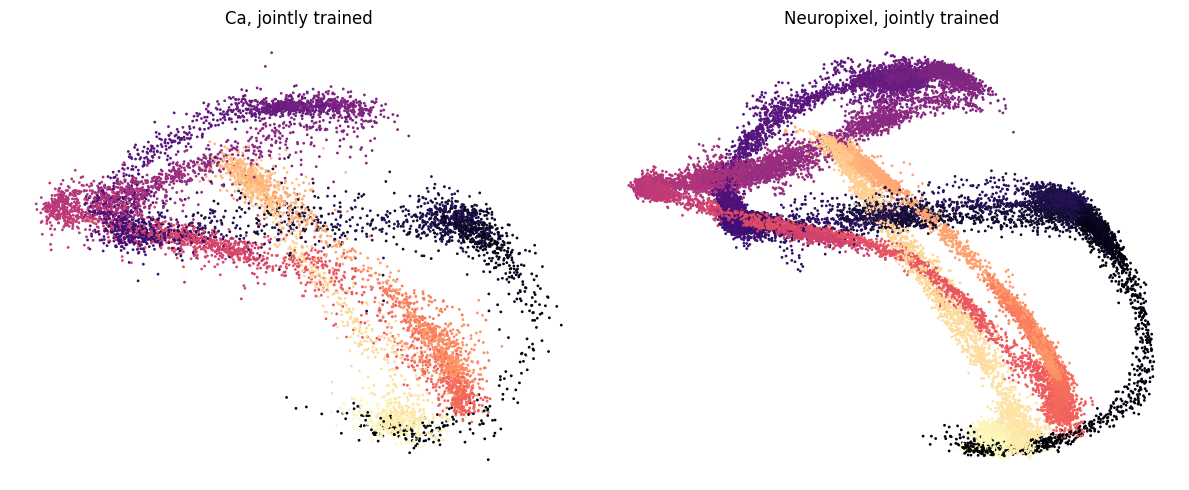

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

ax1 = plt.subplot(121)
ax1.set_title("Ca, jointly trained")
ax1.scatter(
    ca_emb[:, 0],
    ca_emb[:, 1],
    cmap="magma",
    c=np.tile(np.arange(900), 9),
    s=1,
)
ax1.axis("off")

ax2 = plt.subplot(122)
ax2.set_title("Neuropixel, jointly trained")
ax2.scatter(
    np_emb_train[:, 0],
    np_emb_train[:, 1],
    cmap="magma",
    c=np.tile(np.repeat(np.arange(900), 4), 9),
    s=1,
)
ax2.axis("off")

plt.tight_layout()
plt.show()

### Step 3: Neuropixel frame-id decoding (kNN on **train** / **test** `.npy` embeddings only)

Same call pattern as `Demo_Allen.ipynb`: kNN on train embeddings, evaluate on test embeddings (`modality='neuropixel'`).

In [7]:
from sklearn.neighbors import KNeighborsClassifier


def allen_frame_id_decode(
    train_fs, train_labels, test_fs, test_labels, modality="neuropixel", decoder="knn"
):
    """Same logic as Demo_Allen.ipynb; arrays only (no torch / cebra)."""
    if modality == "neuropixel":
        FACTOR = 4
    elif modality == "ca":
        FACTOR = 1
    else:
        raise ValueError(modality)

    time_window = 1

    def feature_for_one_frame(feature):
        arr = np.asarray(feature)
        return arr.reshape(-1, FACTOR, arr.shape[-1]).mean(axis=1)

    train_fs = feature_for_one_frame(train_fs)
    test_fs = feature_for_one_frame(test_fs)

    if decoder != "knn":
        raise ValueError("Only decoder='knn' is used here (matches Demo joint line).")

    params = np.power(np.linspace(1, 10, 5, dtype=int), 2)
    errs = []

    for n in params:
        train_decoder = KNeighborsClassifier(n_neighbors=n, metric="cosine")
        train_valid_idx = int(len(train_fs) / 9 * 8)
        train_decoder.fit(train_fs[:train_valid_idx], train_labels[:train_valid_idx])
        pred = train_decoder.predict(train_fs[train_valid_idx:])
        err = train_labels[train_valid_idx:] - pred
        errs.append(abs(err).sum())

    test_decoder = KNeighborsClassifier(
        n_neighbors=params[np.argmin(errs)], metric="cosine"
    )
    test_decoder.fit(train_fs, train_labels)
    pred = test_decoder.predict(test_fs)
    frame_errors = pred - test_labels

    def _quantize_acc(frame_diff, time_window=1):
        true = (abs(frame_diff) < (time_window * 30)).sum()
        return true / len(frame_diff) * 100

    quantized_acc = _quantize_acc(frame_errors, time_window)
    return pred, frame_errors, quantized_acc


if np_emb_test is None:
    raise FileNotFoundError(
        "Need Neuropixel **test** embedding file in allen_data/, e.g. "
        f"{AREA}_joint_trained_np_{seed}_test.npy"
    )

pred_joint, errs_joint, acc_joint = allen_frame_id_decode(
    np_emb_train,
    np.tile(np.arange(900), 9),
    np_emb_test,
    np.arange(900),
    modality="neuropixel",
    decoder="knn",
)

In [8]:
print(f"joint Neuropixel (train/test embeddings, kNN): {acc_joint:.2f}%")

joint Neuropixel (train/test embeddings, kNN): 81.44%
